In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
from scipy.optimize import minimize, BFGS, NonlinearConstraint
from scipy import optimize

In [2]:
# Styles
import matplotlib as mpl
mpl.rcParams['font.size'] = 12
cm = plt.cm.tab10 # Colormap

In [3]:
from copy import deepcopy
def counted(f):
    def wrapped(*args, **kwargs):
        wrapped.calls += 1
        wrapped.Xk.append(deepcopy(*args))
        return f(*args, **kwargs)
    wrapped.calls = 0
    wrapped.Xk = []
    return wrapped

# auxiliary function to save intermediate points
def store(xk):
    Xk.append(xk)

In [4]:
@counted
def SQF(x):
    '''Slanted quadratic function, beta=[0,2)'''
    beta = 1.5
    return sum(x[:]**2) - beta*x[0]*x[1]
SQF.__name__ = 'SQF'

In [5]:
# definition of objective function and constraints
@counted
def rosen(x):
    '''Rosenbrock function'''
    # 2D: f = 100*(x2 - x1**2)**2 + (1 - x1)**2
    return sum(100.0*(x[1:]-x[:-1]**2.0)**2.0 + (1-x[:-1])**2.0)
rosen.__name__ = 'rosen'

In [6]:
#Якобиан Розенброка
def rosen_der(x):
    xm = x[1:-1]
    xm_m1 = x[:-2]
    xm_p1 = x[2:]
    der = np.zeros_like(x)
    der[1:-1] = 200*(xm-xm_m1**2) - 400*(xm_p1 - xm**2)*xm - 2*(1-xm)
    der[0] = -400*x[0]*(x[1]-x[0]**2) - 2*(1-x[0])
    der[-1] = 200*(x[-1]-x[-2]**2)
    return der

In [7]:
#Гессиан Розенброка
def rosen_hess(x):
    x = np.asarray(x)
    H = np.diag(-400*x[:-1],1) - np.diag(400*x[:-1],-1)
    diagonal = np.zeros_like(x)
    diagonal[0] = 1200*x[0]**2-400*x[1]+2
    diagonal[-1] = 200
    diagonal[1:-1] = 202 + 1200*x[1:-1]**2 - 400*x[2:]
    H = H + np.diag(diagonal)
    return H

In [8]:
# definition of constraints
def ring(x, center, radius, width):
    '''Ring with center [center], radius [radius] and width [width]'''
    r = sum((x - center)**2)**0.5
    return (r - (radius-0.5*width))**2 - (0.5*width)**2

In [9]:
# define ring
Center = np.array([0, 0])
radius, width = 1., 0.2
constr = lambda x: ring(x, Center, radius, width)
print(f'radius = {radius:.5}, width = {width:.5}')

radius = 1.0, width = 0.2


In [10]:
# definition of objective function and constraints
@counted
def jones(x):
    '''Jones function'''
    return x[0]**4 + x[1]**4 - 4*x[0]**3 - 3*x[1]**3 + 2*x[0]**2 + 2*x[0]*x[1]
jones.__name__ = 'jones'

In [11]:
def set_constants(obj_fun):
    '''Set bounds and optimum point'''
    if obj_fun == SQF:
        X_LIM = [-10., 10.]
        F_LIM = [0, 350.]
        X_OPT = [0., 0.]
    
    elif obj_fun == rosen:
        X_LIM = [-1.2, 1.2]
        F_LIM = [0, 680]
        X_OPT = [1., 1.]
    
    elif obj_fun == jones:
        X_LIM = [-1.5, 3.5]
        F_LIM = [-15, 40]
        X_OPT = [2.6732, -0.6759]
    else:
        return None
        
    X_LIM = np.array(X_LIM)
    F_LIM = np.array(F_LIM)
    X_OPT = np.array(X_OPT)
    
    return X_LIM, F_LIM, X_OPT

In [12]:
# functions for visualization
def fun_2d(X1, X2, fun):
    array_2d = np.zeros((len(X1), len(X2)))
    for i, x2 in enumerate(X2):
        for j, x1 in enumerate(X1):
            array_2d[i, j] = fun(np.array([x1, x2]))
    return array_2d

In [13]:
def fun_contours(fun, points=[], constr=None, trajectory=[], figname='', X_LIM = [-10, 10], X2_LIM = None):
    '''Draw function 2D contours'''
    plt.figure(figsize=(4, 4)) 
    F_LIM = ([fun(np.array([X_LIM[0], X_LIM[0]])), fun(np.array([X_LIM[1], X_LIM[1]]))]
             if set_constants(fun) == None
             else (set_constants(fun)[1]))
    X1 = X2 = np.linspace(*X_LIM, 401)
    if X2_LIM == None:
        pass
    else:
        X2 = np.linspace(*X2_LIM, 401)
    # function contours
    z_lines = np.linspace(0, F_LIM[1]**0.5, 20)**2
    if (F_LIM[0] < 0):
        z_lines_1 = np.linspace(F_LIM[0], 0, 20)
        z_lines = np.concatenate((z_lines_1[:-1], z_lines))
    contours = plt.contour(X1, X2, fun_2d(X1,X2,fun), z_lines,
    linewidths=1., colors='k', alpha=0.9)
   
    plt.clabel(contours, fontsize=8, fmt='%.0f')
    # points
    for point in points:
        plt.plot(*point, 'x', c=cm(3), mew=2., ms=15)
    # trajectory
    if (len(trajectory) != 0):
        plt.plot(*trajectory[:,0], 'o', c=cm(0), ms=8)
        plt.plot(*trajectory, '-o', c=cm(0), ms=3.5)
        plt.plot(*trajectory[:,-1], '+', c=cm(0), mew=2., ms=15)
    # constraint
    if constr:
        plt.contour(X1,X2,fun_2d(X1,X2,constr),0,linewidths=1.,colors=cm(1))
    plt.xlabel(r"$x_1$")
    plt.ylabel(r"$x_2$", rotation='horizontal', horizontalalignment='center')
    plt.xlim(X1[0], X1[-1])
    plt.ylim(X2[0], X2[-1])
    plt.tight_layout()
    plt.show()
    if (figname):
        plt.savefig(figname, dpi=200, bbox_inches='tight')

# Задание 1

#### Квадратичная функция. Эта функция дана для тренировки, в зачет не идет, в отчете может не содержаться.

In [14]:
minimize(SQF, set_constants(SQF)[0], method='BFGS',
               options={'disp': True})

Optimization terminated successfully.
         Current function value: 0.000000
         Iterations: 2
         Function evaluations: 12
         Gradient evaluations: 4


  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 3.640956381098073e-12
        x: [-1.020e-06  1.020e-06]
      nit: 2
      jac: [-3.555e-06  3.585e-06]
 hess_inv: [[ 6.429e-01  3.571e-01]
            [ 3.571e-01  6.429e-01]]
     nfev: 12
     njev: 4

In [15]:
minimize(SQF, set_constants(SQF)[0], method='nelder-mead',
               options={'disp': True})

Optimization terminated successfully.
         Current function value: 0.000000
         Iterations: 48
         Function evaluations: 87


       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 9.610300531165774e-10
             x: [ 3.131e-05  4.655e-05]
           nit: 48
          nfev: 87
 final_simplex: (array([[ 3.131e-05,  4.655e-05],
                       [-5.206e-05, -2.769e-05],
                       [-2.772e-05,  3.866e-05]]), array([ 9.610e-10,  1.315e-09,  3.871e-09]))

# Задание 2

#### Функция Розенброка, безусловная оптимизация. Сравнить алгоритмы по количеству вызовов целевой функции.

In [16]:
minimize(rosen, set_constants(rosen)[0], method='BFGS',
               jac=rosen_der,
               options={'disp': True})

Optimization terminated successfully.
         Current function value: 0.000000
         Iterations: 34
         Function evaluations: 45
         Gradient evaluations: 45


  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 9.07406806731599e-15
        x: [ 1.000e+00  1.000e+00]
      nit: 34
      jac: [ 5.393e-07 -1.748e-07]
 hess_inv: [[ 5.279e-01  1.056e+00]
            [ 1.056e+00  2.115e+00]]
     nfev: 45
     njev: 45

In [17]:
minimize(rosen, set_constants(rosen)[0], method='nelder-mead',
               options={'disp': True})

Optimization terminated successfully.
         Current function value: 0.000000
         Iterations: 91
         Function evaluations: 169


       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 5.400895359870943e-10
             x: [ 1.000e+00  1.000e+00]
           nit: 91
          nfev: 169
 final_simplex: (array([[ 1.000e+00,  1.000e+00],
                       [ 1.000e+00,  1.000e+00],
                       [ 1.000e+00,  1.000e+00]]), array([ 5.401e-10,  1.361e-09,  3.098e-09]))

In [18]:
minimize(rosen, set_constants(rosen)[0], method='Newton-CG',
               jac=rosen_der, hess=rosen_hess,
               options={'disp': True})

Optimization terminated successfully.
         Current function value: 0.000000
         Iterations: 94
         Function evaluations: 105
         Gradient evaluations: 105
         Hessian evaluations: 94


 message: Optimization terminated successfully.
 success: True
  status: 0
     fun: 3.093472173285035e-17
       x: [ 1.000e+00  1.000e+00]
     nit: 94
     jac: [ 1.847e-06 -9.272e-07]
    nfev: 105
    njev: 105
    nhev: 94

In [19]:
minimize(rosen, set_constants(rosen)[0], method='trust-ncg',
               jac=rosen_der, hess=rosen_hess,
               options={'disp': True})

Optimization terminated successfully.
         Current function value: 0.000000
         Iterations: 34
         Function evaluations: 35
         Gradient evaluations: 31
         Hessian evaluations: 30


 message: Optimization terminated successfully.
 success: True
  status: 0
     fun: 5.4385889793705684e-11
       x: [ 1.000e+00  1.000e+00]
     nit: 34
     jac: [-2.953e-06 -5.892e-06]
    nfev: 35
    njev: 31
    nhev: 30
    hess: [[ 8.020e+02 -4.000e+02]
           [-4.000e+02  2.000e+02]]

In [20]:
minimize(rosen, set_constants(rosen)[0], method='trust-krylov',
               jac=rosen_der, hess=rosen_hess,
               options={'disp': True})

 iter inewton type    objective     âgââ_Mâ»Â¹      leftmost         Î»             Î³             Î´             Î±             Î²       
     0     0  cg_i -5.782094e+00  1.446718e+00  0.000000e+00  0.000000e+00  1.288727e+02  1.436172e+03  6.962956e-04  1.260219e-04

 iter inewton type    objective     âgââ_Mâ»Â¹      leftmost         Î»             Î³             Î´             Î±             Î²       
     0     0  cg_i -4.865136e-02  1.725923e+00  0.000000e+00  0.000000e+00  1.068450e+01  1.173230e+03  8.523477e-04  2.609364e-02

 iter inewton type    objective     âgââ_Mâ»Â¹      leftmost         Î»             Î³             Î´             Î±             Î²       
     0     0  cg_i -1.271602e-01  1.740098e+01  0.000000e+00  0.000000e+00  1.743103e+00  1.194716e+01  8.370190e-02  9.965554e+01

 TR Solving trust region problem, radius 1.000000e+00; starting on first irreducible block
 TR Coldstart. Seeking suitable initial Î»â, starting with 0
 TR  Î»â =

 TR Solving trust region problem, radius 6.250000e-02; starting on first irreducible block
 TR Starting Newton iteration for Î»â with initial choice 4.418100e+00
 TR  iter        Î»            dÎ»       âhâ(Î»)â-radius
 TR      1  2.460855e+01  2.019045e+01  4.611478e-06
 TR      2  2.461054e+01  1.986612e-03  7.252532e-14
 TR Newton breakdown, dÎ» = 3.124601e-11 Î» = 2.461054e+01

 iter inewton type    objective     Î³áµ¢ââ|háµ¢|      leftmost         Î»             Î³             Î´       
     1     3   hot -1.007251e-01  0.000000e+00  0.000000e+00  2.461054e+01  2.481063e+01  2.107976e+02

Early exit as hotstart with early termination on

 iter inewton type    objective     âgââ_Mâ»Â¹      leftmost         Î»             Î³             Î´             Î±             Î²       
     0     0  cg_i -3.878766e-02  3.679644e+00  0.000000e+00  0.000000e+00  1.629379e+00  3.422321e+01  2.921994e-02  5.099966e+00

 TR Solving trust region problem, radius 1.250000e-01; star

 iter inewton type    objective     âgââ_Mâ»Â¹      leftmost         Î»             Î³             Î´             Î±             Î²       
     0     0  cg_i -1.220163e-03  1.453901e-02  0.000000e+00  0.000000e+00  1.547162e+00  9.808983e+02  1.019474e-03  8.830763e-05

 iter inewton type    objective     âgââ_Mâ»Â¹      leftmost         Î»             Î³             Î´             Î±             Î²       
     0     0  cg_i -3.021088e-06  7.510153e-02  0.000000e+00  0.000000e+00  1.388113e-02  3.189012e+01  3.135767e-02  2.927170e+01

 iter inewton type    objective     âgââ_Mâ»Â¹      leftmost         Î»             Î³             Î´             Î±             Î²       
     0     0  cg_i -4.863669e-06  2.594567e-04  0.000000e+00  0.000000e+00  9.869370e-02  1.001348e+03  9.986542e-04  6.911160e-06

 iter inewton type    objective     âgââ_Mâ»Â¹      leftmost         Î»             Î³             Î´             Î±             Î²       
     0     0  cg_i -

 message: Optimization terminated successfully.
 success: True
  status: 0
     fun: 6.74137867036309e-13
       x: [ 1.000e+00  1.000e+00]
     nit: 36
     jac: [ 3.260e-05 -1.637e-05]
    nfev: 37
    njev: 37
    nhev: 32
    hess: [[ 8.020e+02 -4.000e+02]
           [-4.000e+02  2.000e+02]]

In [21]:
minimize(rosen, set_constants(rosen)[0], method='trust-exact',
               jac=rosen_der, hess=rosen_hess,
               options={'disp': True})

Optimization terminated successfully.
         Current function value: 0.000000
         Iterations: 24
         Function evaluations: 25
         Gradient evaluations: 22
         Hessian evaluations: 25


 message: Optimization terminated successfully.
 success: True
  status: 0
     fun: 3.2700463608450604e-15
       x: [ 1.000e+00  1.000e+00]
     nit: 24
     jac: [ 1.863e-06 -9.625e-07]
    nfev: 25
    njev: 22
    nhev: 25
    hess: [[ 8.020e+02 -4.000e+02]
           [-4.000e+02  2.000e+02]]

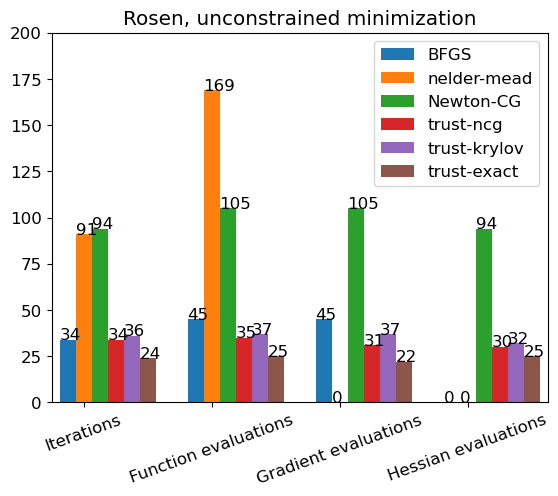

In [22]:
columns = ("Iterations", "Function evaluations", "Gradient evaluations", "Hessian evaluations")
data = {
    'BFGS': (34, 45, 45, 0),
    'nelder-mead': (91, 169, 0, 0),
    'Newton-CG': (94, 105, 105, 94),
    'trust-ncg': (34, 35, 31, 30),
    'trust-krylov': (36, 37, 37, 32),
    'trust-exact': (24, 25, 22, 25),
}

x = np.arange(len(columns)) 
width = 1. / 8.
multiplier = 0

fig, ax = plt.subplots()

for ind, (attribute, measurement) in enumerate(data.items()):
    offset = width * multiplier
    ax.bar(x + offset, measurement, width, label=attribute)
    
    for i in range(len(x + offset)):
        plt.text((x + offset)[i]-width/2, measurement[i], measurement[i])
    
    multiplier += 1

ax.set_title('Rosen, unconstrained minimization')

ax.set_xticks(x + width)
ax.set_xticklabels(columns, rotation = 20)

ax.legend(loc='upper right')

ax.set_ylim(0, 200)
ax.set_xlim(-width, x[-1] + width * multiplier)

plt.show()

Были рассмотрены все возможные методы безусловной оптимизации доступные scipy.optimize.minimize
Некоторые требовали Якобиан или Гессиан рассмариваемой функции, там где они были не нужны, значения их вызовов было принято равным нулю

# Задание 3

#### Функция Розенброка, условная оптимизация. Исследовать способность алгоритмов находить условный минимум, предложить способ решения проблемы локальных минимумов. Для алгоритмов, не поддерживающих работу с нелинейными ограничениями, использовать метод штрафов.

In [23]:
#Функия штрафов
def penalty_function(x, r = 1):
    return rosen(x) + r * np.maximum(constr(x), 0)**2

In [24]:
r = 1
result_2_1 = minimize(lambda x: penalty_function(x, r), set_constants(rosen)[0])

while constr(result_2_1.x) > 0:
    r *= 10
    result_2_1 = minimize(lambda x: penalty_function(x, r), set_constants(rosen)[0])

print("Оптимальное значение x:", result_2_1.x)
print("Минимальное значение функции rosen(x):", rosen(result_2_1.x))

Оптимальное значение x: [-0.71048952  0.51071488]
Минимальное значение функции rosen(x): 2.929278478707953


In [25]:
#Нелинейные ограничения
nonlinear_constraint = NonlinearConstraint(constr, -np.inf, 0, jac='2-point', hess=BFGS())

In [26]:
result_2_2 = minimize(rosen, set_constants(rosen)[0], method='SLSQP',
               constraints=[nonlinear_constraint])

print("Оптимальное значение x:", result_2_2.x)
print("Минимальное значение функции rosen(x):", rosen(result_2_2.x))

Оптимальное значение x: [-0.71044633  0.51077491]
Минимальное значение функции rosen(x): 2.929275930545692


In [27]:
#В случае локальных минимумов shgo находит их все в заданном диапазоне, а также находит среди них глобальный
result_2_3 = optimize.shgo(rosen, [tuple(set_constants(rosen)[0]), tuple(set_constants(rosen)[0])], n=200, iters=5,
                           sampling_method='sobol', options={}, 
                           constraints=({'type': 'ineq', 'fun': lambda x: -constr(x)}))

D:\Telegram Desktop\anaconda3\lib\site-packages\scipy\optimize\_optimize.py:353: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "


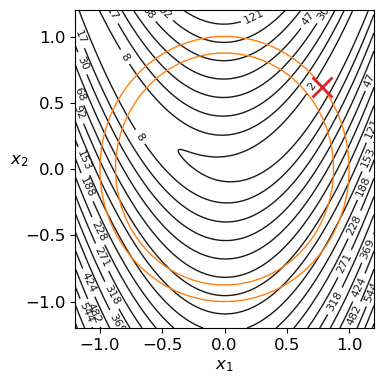

In [28]:
fun_contours(rosen, points=[result_2_3.x], constr=constr, X_LIM = set_constants(rosen)[0])

# Задание 4

### Две пружинки
#### Груз массой закреплён на двух недеформированных пружинах 1, 1 и 2, 2 (см. рисунок).
#### Найти положение равновесия системы для 1 = 1, 1 = 12, 2 = 9, 2 = 7, = 0.7.

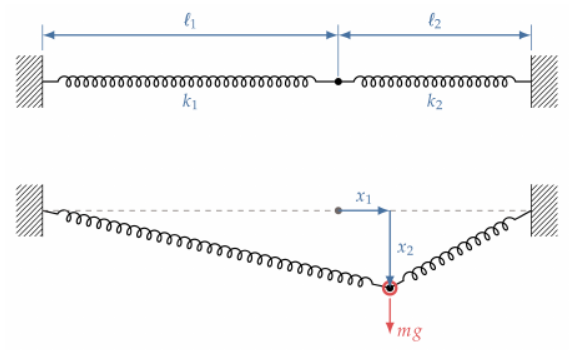

In [29]:
def task_4(l1 = 12, l2 = 7, k1 = 1, k2 = 9, m = 0.7, g = 9.8):
    
    #Норма действующих на груз сил, задача оптимизации - поиск минимального занчения
    def that(num):
        x = num[0]
        y = num[1]
        
        f1 = k1 * (np.array([-l1 - x, -y])/np.linalg.norm([-l1 - x, -y]) * (np.linalg.norm([l1 + x, y]) - l1))
        f2 = k2 * (np.array([l2 - x, -y])/np.linalg.norm([l2 - x, -y]) * (np.linalg.norm([l2 - x, y]) - l2))
        mg = m * g * np.array([0, 1])
        return np.linalg.norm(f1 + f2 + mg)
    
    #Поиск минимумов методом shgo, ограничение - груз не выше оси крепления пружин и не выходит за пределы конструкции
    result_4_1 = optimize.shgo(that, [(-l1, l2), (-1, 10)], n=200, iters=5,
                           sampling_method='sobol', options={}, 
                           constraints=({'type': 'ineq', 'fun': lambda x: x[1]},
                                       {'type': 'ineq', 'fun': lambda x: x[0] + l1 - 1e-3},
                                       {'type': 'ineq', 'fun': lambda x: l2 - x[0] - 1e-3}))
    
    fun_contours(that, [result_4_1.x], X_LIM =[-l1, l2], X2_LIM =[-1, 10])

    #Упрощение решения задачи вручную, проекция действующих сил на оси OX, OY, Решение нелинейной системы optimize.root
    def by_hand(num):
        x = num[0]
        y = num[1]
        
        l1_1 = ((l1 + x)**2 + y**2)**0.5
        l2_1 =  ((l2 - x)**2 + y**2)**0.5
        
        return np.array([k2 * (l2_1 - l2) * (l2 - x) / l2_1 - k1 * (l1_1 - l1) * (l1 + x) / l1_1,
                  k2 * (l2_1 - l2) * y / l2_1 + k1 * (l1_1 - l1) * y / l1_1 - m * g])
    result_4_2 = optimize.root(by_hand, x0 = [0, 0])
    
    print(f"Оптимальное значение - {result_4_1.x}\nАналитическое решение - {result_4_2.x}\nМинимальное значение оптимальной функции - {that(result_4_1.x)}\nМинимальные значения аналитической функции - {by_hand(result_4_2.x)}")

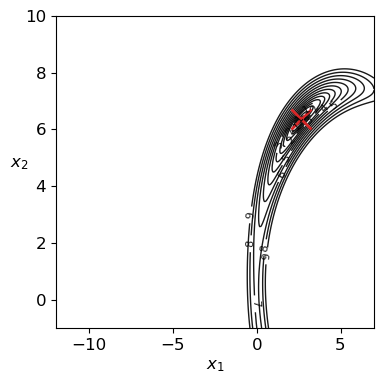

Оптимальное значение - [2.63445016 6.35763955]
Аналитическое решение - [2.63445016 6.35763955]
Минимальное значение оптимальной функции - 1.6496046278531943e-09
Минимальные значения аналитической функции - [ 2.17736940e-12 -1.76978432e-11]


In [30]:
 task_4()

#### Оптимизация:
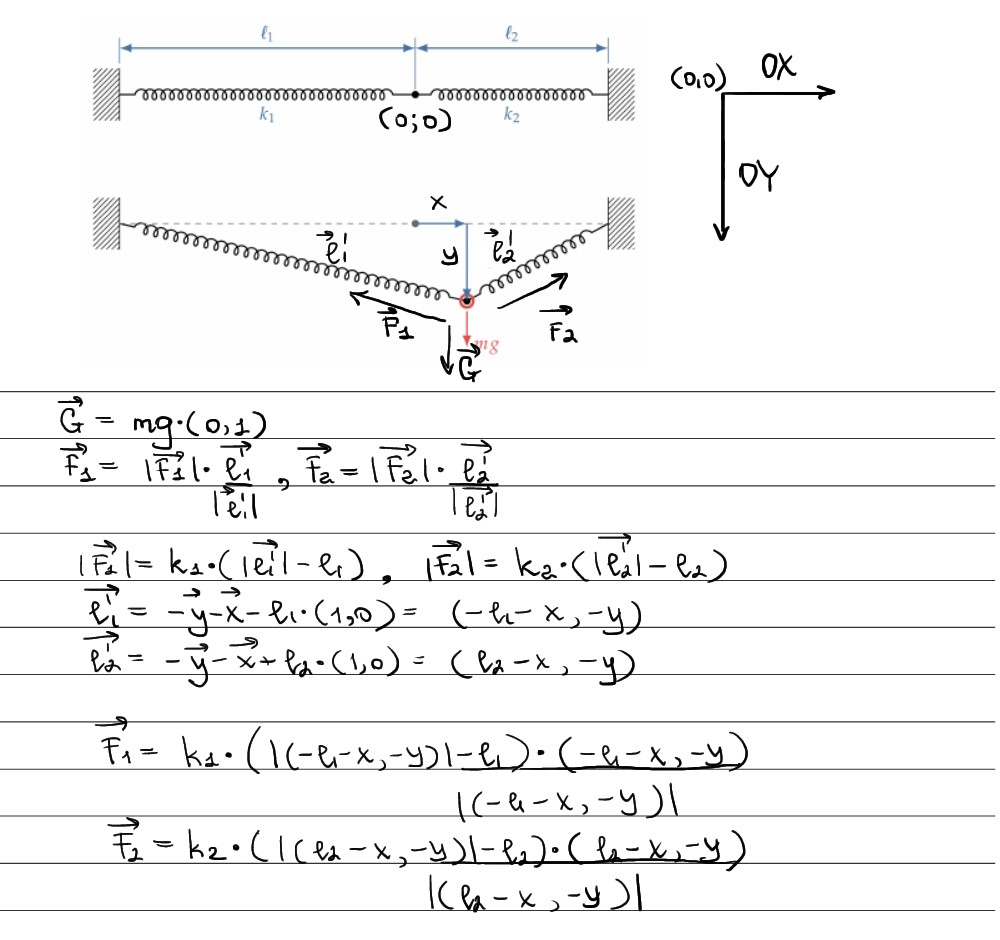

#### Аналитический
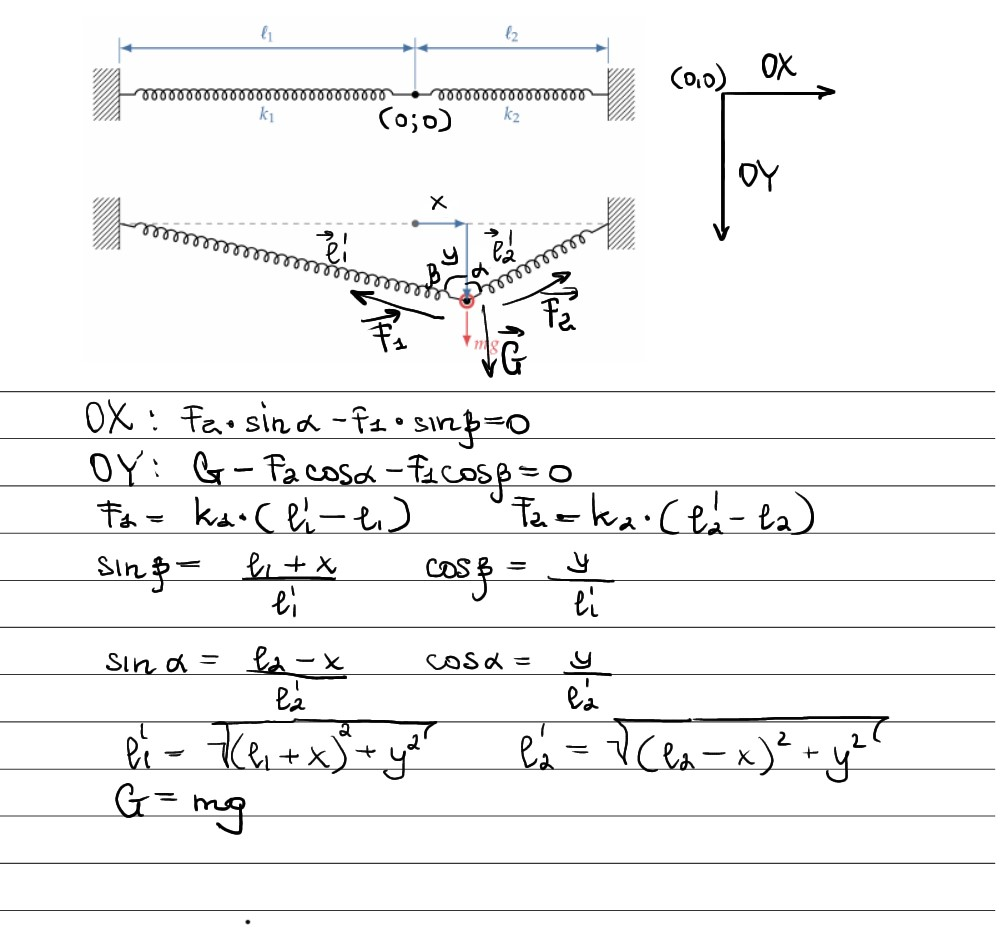